# Lab 2: Classification Using KNN and RNN Algorithms

**Name:** Pawan Sharma

**Course:** MSCS-634-M50 - Advanced Big Data and Data Mining

**Lab 2:** Classification Using KNN and RNN Algorithms

## Dataset

- **Dataset:** Wine Dataset
- **Source:** scikit-learn (`sklearn.datasets.load_wine`)

There are 178 instances of wines from 3 distinct vintners (classes 0, class 1 and class 2). These instances have 13 different attributes each like alcohol, malic acid, magnesium, flavanoids, hue and proline.

## Objective

Here I will analyze the comparison between two kinds of neighbor classifiers, namely the K-Nearest Neighbors (KNN) and the Radius Neighbors (RNN). I will change the values of k for KNN classifier and the values of radius for RNN classifier. I will take note of the test accuracies and plot the trend.

## 1. Import Libraries

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier, RadiusNeighborsClassifier
from sklearn.metrics import accuracy_score

pd.set_option("display.max_columns", None)

print("Libraries imported successfully.")

Libraries imported successfully.


## 2. Load the Wine Dataset

In [4]:
wine = load_wine()

X = pd.DataFrame(wine.data, columns=wine.feature_names)
y = pd.Series(wine.target, name="class")

df = X.copy()
df["class"] = y

print("Dataset loaded successfully.")
print("Rows:", df.shape[0])
print("Columns (13 features + class):", df.shape[1])
print("Class names:", [str(n) for n in wine.target_names])

Dataset loaded successfully.
Rows: 178
Columns (13 features + class): 14
Class names: ['class_0', 'class_1', 'class_2']


## 3. Display First Five Rows

In [5]:
df.head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,class
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0


## 4. Feature Details

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 14 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   alcohol                       178 non-null    float64
 1   malic_acid                    178 non-null    float64
 2   ash                           178 non-null    float64
 3   alcalinity_of_ash             178 non-null    float64
 4   magnesium                     178 non-null    float64
 5   total_phenols                 178 non-null    float64
 6   flavanoids                    178 non-null    float64
 7   nonflavanoid_phenols          178 non-null    float64
 8   proanthocyanins               178 non-null    float64
 9   color_intensity               178 non-null    float64
 10  hue                           178 non-null    float64
 11  od280/od315_of_diluted_wines  178 non-null    float64
 12  proline                       178 non-null    float64
 13  class           

In [7]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
alcohol,178.0,13.000618,0.811827,11.03,12.3625,13.050,13.6775,14.83
malic_acid,178.0,2.336348,1.117146,0.74,1.6025,1.865,3.0825,5.80
ash,178.0,2.366517,0.274344,1.36,2.2100,2.360,2.5575,3.23
alcalinity_of_ash,178.0,19.494944,3.339564,10.60,17.2000,19.500,21.5000,30.00
magnesium,178.0,99.741573,14.282484,70.00,88.0000,98.000,107.0000,162.00
total_phenols,178.0,2.295112,0.625851,0.98,1.7425,2.355,2.8000,3.88
flavanoids,178.0,2.029270,0.998859,0.34,1.2050,2.135,2.8750,5.08
nonflavanoid_phenols,178.0,0.361854,0.124453,0.13,0.2700,0.340,0.4375,0.66
proanthocyanins,178.0,1.590899,0.572359,0.41,1.2500,1.555,1.9500,3.58
color_intensity,178.0,5.058090,2.318286,1.28,3.2200,4.690,6.2000,13.00


### Feature Range Interpretation

From the summary table above, it can be seen that the features are on very different scales. In this respect, it is important to note that hue and nonflavanoid phenols are values less than 2 while magnesium is about 100 and proline varies from 278 to 1680. It is extremely important for neighbor-based methods since both KNN and RNN use Euclidean distance. Without normalization, proline feature will play an overwhelming role in the difference between two samples.

Features were left on their original scale in order to conduct the experiment. Values of the radius provided in the lab (350 to 600) are reasonable for raw data only since the average difference between points becomes several units after applying standard scaling and therefore a radius of 350 will encompass all samples of the training set.

## 5. Missing-Value Check

In [8]:
print("Total missing values:", df.isnull().sum().sum())

Total missing values: 0


## 6. Class Distribution

In [9]:
class_counts = df["class"].value_counts().sort_index()

class_summary = pd.DataFrame({
    "Class": [wine.target_names[i] for i in class_counts.index],
    "Count": class_counts.values,
    "Percentage": (class_counts.values / len(df) * 100).round(2)
})

class_summary

,Class,Count,Percentage
0,class_0,59,33.15
1,class_1,71,39.89
2,class_2,48,26.97


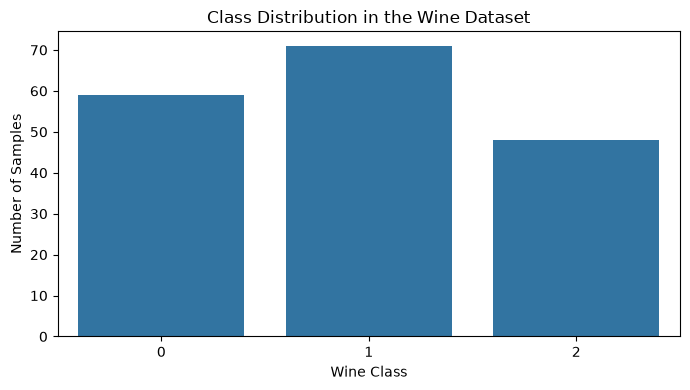

In [10]:
plt.figure(figsize=(7, 4))

sns.countplot(x="class", data=df)

plt.title("Class Distribution in the Wine Dataset")
plt.xlabel("Wine Class")
plt.ylabel("Number of Samples")

plt.tight_layout()
plt.show()

### Class Distribution Interpretation

There are 59 samples in class 0, 71 samples in class 1, and 48 samples in class 2. The classes are not entirely balanced, but there is no significant imbalance as well. Due to this slight imbalance, I have applied stratified sampling so that the training and testing data set maintain a similar distribution of classes as well.

## 7. Train-Test Split (80% / 20%)

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])
print()
print("Training class counts:", y_train.value_counts().sort_index().tolist())
print("Testing class counts:", y_test.value_counts().sort_index().tolist())

Training samples: 142
Testing samples: 36

Training class counts: [47, 57, 38]
Testing class counts: [12, 14, 10]


## 8. K-Nearest Neighbors (KNN)

KNN classifies a test case using its k nearest training cases and finds out the most prevalent class among them. The value of k was set to 1, 5, 11, 15 and 21.

In [12]:
k_values = [1, 5, 11, 15, 21]
knn_results = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)

    y_pred = knn.predict(X_test)
    acc = accuracy_score(y_test, y_pred)

    knn_results.append({"k": k, "Accuracy": acc})
    print(f"k = {k:>2}  ->  Accuracy = {acc:.4f}")

knn_df = pd.DataFrame(knn_results)
knn_df

k =  1  ->  Accuracy = 0.7778
k =  5  ->  Accuracy = 0.8056
k = 11  ->  Accuracy = 0.8056
k = 15  ->  Accuracy = 0.8056
k = 21  ->  Accuracy = 0.8056


,k,Accuracy
0,1,0.777778
1,5,0.805556
2,11,0.805556
3,15,0.805556
4,21,0.805556


### KNN Results Interpretation

At k = 1, the accuracy was the lowest (around 77.8%). With only one neighbor, the prediction will depend totally on the nearest data point, and thus, any noisy or weird data point might lead to erroneous predictions. Starting from k = 5, the accuracy rose to around 80.6%, and remained unchanged even at k = 11, 15 and 21. The more neighbors we use, the smoother the decision becomes; in this case set, no change happened from k = 5 onwards.

## 9. Radius Neighbors (RNN)

RNN does not consider a constant number of neighbors. Rather, it considers all the training samples within a certain radius around the test sample and performs a vote among the majority of them. I tried radius sizes of 350, 400, 450, 500, 550, and 600.

To ensure safety against test samples with no neighbors, I set `outlier_label="most_frequent"`. If there were no training samples within a certain radius around a test sample, then the most frequent label was used for prediction rather than causing a problem. I recorded the number of test samples with no neighbors and the average number of neighbors found to account for accuracy.

In [13]:
radius_values = [350, 400, 450, 500, 550, 600]
rnn_results = []

for r in radius_values:
    rnn = RadiusNeighborsClassifier(radius=r, outlier_label="most_frequent")
    rnn.fit(X_train, y_train)

    y_pred = rnn.predict(X_test)
    acc = accuracy_score(y_test, y_pred)

    neighbors = rnn.radius_neighbors(X_test, return_distance=False)
    avg_neighbors = np.mean([len(n) for n in neighbors])
    no_neighbors = sum(len(n) == 0 for n in neighbors)

    rnn_results.append({
        "Radius": r,
        "Accuracy": acc,
        "Avg Neighbors": round(avg_neighbors, 1),
        "Test Points With No Neighbors": no_neighbors
    })
    print(f"radius = {r}  ->  Accuracy = {acc:.4f}  (avg neighbors = {avg_neighbors:.1f})")

rnn_df = pd.DataFrame(rnn_results)
rnn_df

radius = 350  ->  Accuracy = 0.7222  (avg neighbors = 80.5)
radius = 400  ->  Accuracy = 0.6944  (avg neighbors = 87.9)
radius = 450  ->  Accuracy = 0.6944  (avg neighbors = 94.8)
radius = 500  ->  Accuracy = 0.6944  (avg neighbors = 100.1)
radius = 550  ->  Accuracy = 0.6667  (avg neighbors = 106.0)
radius = 600  ->  Accuracy = 0.6667  (avg neighbors = 111.0)


,Radius,Accuracy,Avg Neighbors,Test Points With No Neighbors
0,350,0.722222,80.5,0
1,400,0.694444,87.9,0
2,450,0.694444,94.8,0
3,500,0.694444,100.1,0
4,550,0.666667,106.0,0
5,600,0.666667,111.0,0


### RNN Results Interpretation

The optimal RNN accuracy was for radius 350 (about 72.2%). With increasing radius value, the accuracy decreased from 72.2% for radius 350 up to 69.4% for radius 400 to 500 and to 66.7% for radius 550 to 600. The reason behind the decreasing accuracy is the Neighbor Count column. For radius 350, each test instance already had 80 samples of training set data within the radius distance, while it is slightly less than half of 142 samples. This number increased to 111 samples for radius 600. As soon as the number of samples gets so high, instances of other classes start having a say in the prediction and gradually push the point towards the majority class of the big neighborhood area.

## 10. Visualization 1 — KNN Accuracy vs. k

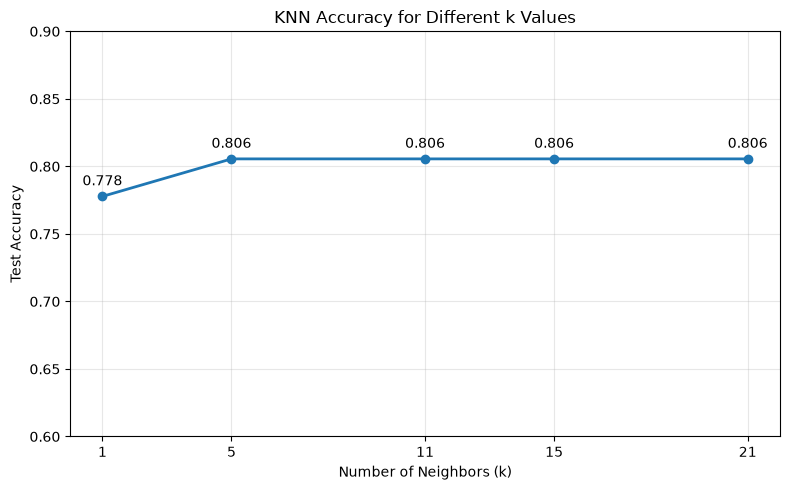

In [14]:
plt.figure(figsize=(8, 5))

plt.plot(knn_df["k"], knn_df["Accuracy"], marker="o", linewidth=2)

for k, acc in zip(knn_df["k"], knn_df["Accuracy"]):
    plt.annotate(f"{acc:.3f}", (k, acc), textcoords="offset points", xytext=(0, 8), ha="center")

plt.title("KNN Accuracy for Different k Values")
plt.xlabel("Number of Neighbors (k)")
plt.ylabel("Test Accuracy")
plt.xticks(k_values)
plt.ylim(0.6, 0.9)
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 11. Visualization 2 — RNN Accuracy vs. Radius

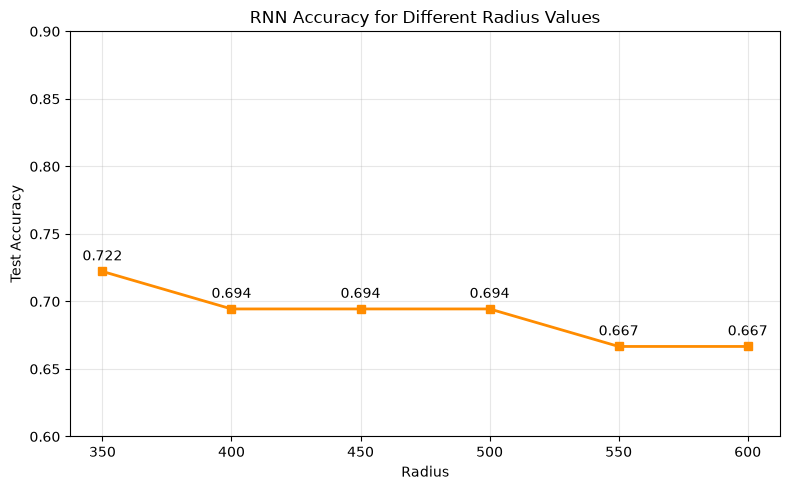

In [15]:
plt.figure(figsize=(8, 5))

plt.plot(rnn_df["Radius"], rnn_df["Accuracy"], marker="s", linewidth=2, color="darkorange")

for r, acc in zip(rnn_df["Radius"], rnn_df["Accuracy"]):
    plt.annotate(f"{acc:.3f}", (r, acc), textcoords="offset points", xytext=(0, 8), ha="center")

plt.title("RNN Accuracy for Different Radius Values")
plt.xlabel("Radius")
plt.ylabel("Test Accuracy")
plt.xticks(radius_values)
plt.ylim(0.6, 0.9)
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 12. Visualization 3 — Side-by-Side Comparison

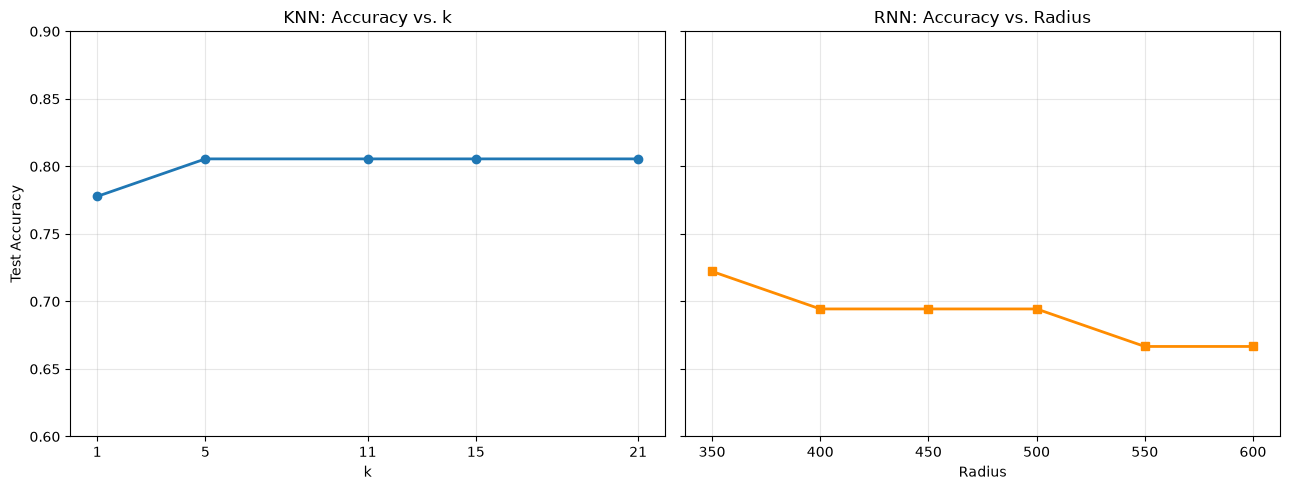

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)

axes[0].plot(knn_df["k"], knn_df["Accuracy"], marker="o", linewidth=2)
axes[0].set_title("KNN: Accuracy vs. k")
axes[0].set_xlabel("k")
axes[0].set_ylabel("Test Accuracy")
axes[0].set_xticks(k_values)
axes[0].grid(alpha=0.3)

axes[1].plot(rnn_df["Radius"], rnn_df["Accuracy"], marker="s", linewidth=2, color="darkorange")
axes[1].set_title("RNN: Accuracy vs. Radius")
axes[1].set_xlabel("Radius")
axes[1].set_xticks(radius_values)
axes[1].grid(alpha=0.3)

plt.ylim(0.6, 0.9)
plt.tight_layout()
plt.show()

## 13. Best Result From Each Model

In [17]:
best_knn = knn_df.loc[knn_df["Accuracy"].idxmax()]
best_rnn = rnn_df.loc[rnn_df["Accuracy"].idxmax()]

comparison = pd.DataFrame({
    "Model": ["KNN", "RNN"],
    "Best Parameter": [f"k = {int(best_knn['k'])}", f"radius = {int(best_rnn['Radius'])}"],
    "Best Accuracy": [round(best_knn["Accuracy"], 4), round(best_rnn["Accuracy"], 4)],
    "Lowest Accuracy": [round(knn_df["Accuracy"].min(), 4), round(rnn_df["Accuracy"].min(), 4)]
})

comparison

,Model,Best Parameter,Best Accuracy,Lowest Accuracy
0,KNN,k = 5,0.8056,0.7778
1,RNN,radius = 350,0.7222,0.6667


## 14. Additional Check — Effect of Feature Scaling on KNN

In examining the results, I decided to verify the impact of the unnormalized `proline` attribute on the models by performing KNN once again using normalized attributes. This is merely an additional finding that is not included in the analysis of the required models since the provided radius values cannot be applied to the normalized data.

In [18]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

scaled_results = []

for k in k_values:
    model = make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=k))
    model.fit(X_train, y_train)
    acc = accuracy_score(y_test, model.predict(X_test))
    scaled_results.append({"k": k, "Unscaled Accuracy": knn_df.loc[knn_df["k"] == k, "Accuracy"].values[0],
                           "Scaled Accuracy": acc})

pd.DataFrame(scaled_results)

,k,Unscaled Accuracy,Scaled Accuracy
0,1,0.777778,0.972222
1,5,0.805556,0.972222
2,11,0.805556,1.000000
3,15,0.805556,1.000000
4,21,0.805556,1.000000


### Scaling Interpretation

With the standardization of the features, the accuracy of the KNN algorithm increased from about 78% to 81% to 97% to 100%, irrespective of the value of k. It backs my findings from the feature summary. With the raw dataset, the distance computation is dominated by `proline`, and to some degree by `magnesium`. The rest of the eleven chemical properties do not play much part.

## 15. Comparison and Observations

**Comparison of KNN and RNN performance.** In this case, the KNN algorithm worked better than RNN in all cases I tried. KNN had its maximum accuracy of about 80.6% (k > 5), whereas the maximum accuracy of RNN was 72.2% with a radius of 350. Another difference between the two algorithms was that they showed different behavior regarding their parameters.

**Why RNN performed worse in this scenario.** The values for radius used in this experiment are quite large relative to the proximity of samples to each other. Even the smallest value of radius, which was 350, ended up selecting over half the training set samples for each test sample. At this stage, RNN performs almost similarly as an extremely large value for k since even distant samples belonging to different classes end up having the same voting power as those near the test point. In KNN, however, only the k nearest samples are selected.

**When KNN may work better.** KNN is suitable for cases when the data distribution density varies across regions, or when I have no idea about the average distance between data points beforehand. The selection of k is more straightforward than that of the radius, since k doesn't depend on the measurement units used for features. As seen from my results, KNN wins over RadiusNeighbors.

**In situations when RNN would make more sense.** The RNN technique would be more appropriate in cases when there is some meaningful physical or domain-specific distance, such as "any location within 5 km." Moreover, RNN would be applicable in case of identification of outliers since the points without any neighbors within the radius are obviously outliers. At the same time, there is needed an appropriate selection of radius, which greatly depends on the choice of feature scaling. If the radius is too large, like it happened here, the local nature of the model gets lost.

## Final Analysis

For this lab, I have used the Wine Dataset from scikit learn to perform classification using KNN and Radius Neighbors classifier. It consists of 178 instances, 13 chemical properties and 3 classes. This dataset does not have any null values in it. Both the train and test datasets consist of 80% and 20% data respectively.

With KNN, accuracy ranged from around 77.8% with k=1 to around 80.6% with k=5, and it remained at this level for k = 11, 15 and 21. In the case of RNN, highest accuracy of around 72.2% was obtained with radius of 350, while it decreased gradually to 66.7% with radius of 600. Using the number of neighbors in the radius, it is evident that radius values have become sufficiently large to encompass most of the training data.

The key learning from this is that the choice of parameters and the scale of the features are very much intertwined when working with neighbor-based approaches. The additional analysis with the standardized features revealed that the actual values of `proline` were dictating the distance computations, and normalization led to better performance of the KNN algorithm. In case I had to create an actual model based on this data set, I would start with normalizing the features, and tuning the parameter k (or a far smaller radius).